<a href="https://colab.research.google.com/github/35397/ml_exp/blob/main/Drone_Detection_Yolo_RCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download("cybersimar08/drone-detection")

print("Path to dataset files:", path)

100%|██████████| 499M/499M [00:13<00:00, 38.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3


In [2]:
!pip install ultralytics torch torchvision albumentations pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.1 MB/s eta 0:00:00


In [3]:
import numpy as np
import os

from ultralytics import YOLO
import albumentations as A
from pycocotools.cocoeval import COCOeval
from pycocotools.coco import COCO
import json
import cv2

import torch
import torchvision
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler
from torch.amp import autocast

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
print(os.listdir(path))

['tensorflow obj detection drone', 'drone-detection-new.v5-new-train.yolov8', 'coco json drone detection']


In [5]:
yolo_path = os.path.join(path, "drone-detection-new.v5-new-train.yolov8")
coco_path = os.path.join(path, "coco json drone detection")

In [6]:
# yolo идет ввиде эталона для сравнения
yolo_model = YOLO("yolov8n.pt")
yolo_model.train(
    data=os.path.join(yolo_path, "data.yaml"),
    epochs=20,
    imgsz=640,
    batch=16,
    device=0
)
# map для всех моделей
metrics = yolo_model.val()
print(metrics.box.map)      # mAP50-95
print(metrics.box.map50)    # mAP@50

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/drone-detection-new.v5-new-train.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False,

In [7]:
yolo_model.predict(
    source=os.path.join(yolo_path, "valid/images"),
    conf=0.25,
    save=True
)


image 1/603 /root/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/drone-detection-new.v5-new-train.yolov8/valid/images/V_AIRPLANE_0011_056_png.rf.dbdfc2c5a59d29d4a8285b306607037b.jpg: 640x640 1 AirPlane, 8.4ms
image 2/603 /root/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/drone-detection-new.v5-new-train.yolov8/valid/images/V_AIRPLANE_0011_114_png.rf.22cd928b6b2eadc0e32ebdb541b394d0.jpg: 640x640 1 AirPlane, 7.3ms
image 3/603 /root/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/drone-detection-new.v5-new-train.yolov8/valid/images/V_AIRPLANE_0011_187_png.rf.34139da037f3be8f0e0b4bb28bbdeb2e.jpg: 640x640 1 AirPlane, 7.2ms
image 4/603 /root/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/drone-detection-new.v5-new-train.yolov8/valid/images/V_AIRPLANE_0011_200_png.rf.cb58e16baac750b2f33902759b3afec6.jpg: 640x640 1 AirPlane, 7.2ms
image 5/603 /root/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/dro

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'AirPlane', 1: 'Drone', 2: 'Helicopter'}
 obb: None
 orig_img: array([[[185, 174, 170],
         [185, 174, 170],
         [185, 174, 170],
         ...,
         [186, 167, 162],
         [186, 167, 162],
         [186, 167, 162]],
 
        [[185, 174, 170],
         [185, 174, 170],
         [185, 174, 170],
         ...,
         [186, 167, 162],
         [186, 167, 162],
         [186, 167, 162]],
 
        [[185, 174, 170],
         [185, 174, 170],
         [185, 174, 170],
         ...,
         [186, 167, 162],
         [186, 167, 162],
         [186, 167, 162]],
 
        ...,
 
        [[ 43,  52,  49],
         [ 43,  52,  49],
         [ 43,  52,  49],
         ...,
         [ 48,  42,  47],
         [ 48,  42,  47],
         [ 48,  42,  47]],
 
        [[ 43,  52,  49],
         [ 43,  52,  49],
         [ 43,  52,  49],
 

In [8]:
#аугментация
transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.1,
            rotate_limit=10,
            p=0.5
        ),
        A.Resize(512, 512)
    ],
    bbox_params=A.BboxParams(
        format='pascal_voc',
        label_fields=['labels'],
        min_visibility=0.3
    )
)
#полная подготовка данных
class DroneDataset(Dataset):
    def __init__(self, root, annotation, transforms=None):
        self.root = root
        self.transforms = transforms
        with open(annotation) as f:
            coco = json.load(f)
        self.images = coco["images"]
        self.annotations = coco["annotations"]
        self.img_to_anns = {}
        for ann in self.annotations:
            self.img_to_anns.setdefault(ann["image_id"], []).append(ann)
        self.images = [img for img in self.images if img["id"] in self.img_to_anns]

    def __getitem__(self, idx):
        img_info = self.images[idx]
        img_path = os.path.join(self.root, img_info["file_name"])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        anns = self.img_to_anns.get(img_info["id"], [])

        boxes, labels = [], []

        for ann in anns:
            x, y, w, h = ann["bbox"]
            boxes.append([x, y, x+w, y+h])
            labels.append(1)

        if len(boxes) == 0:
            return self.__getitem__((idx + 1) % len(self))

        if self.transforms:
            transformed = self.transforms(
                image=img,
                bboxes=boxes,
                labels=labels
            )
            img = transformed["image"]
            boxes = transformed["bboxes"]
            labels = transformed["labels"]
        if len(boxes) == 0:
          return self.__getitem__((idx + 1) % len(self))
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes,"labels": labels,
                  "image_id": torch.tensor(img_info["id"])}

        img = torch.as_tensor(img, dtype=torch.float32).permute(2,0,1) / 255.0

        return img, target

    def __len__(self):
        return len(self.images)

#loader
def collate_fn(batch):
    return tuple(zip(*batch))

train_dataset = DroneDataset(
    os.path.join(coco_path, "train"),
    os.path.join(coco_path, "train/_annotations.coco.json"),
    transforms=transform
)

val_dataset = DroneDataset(
    os.path.join(coco_path, "valid"),
    os.path.join(coco_path, "valid/_annotations.coco.json"),
    transforms=None
)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [9]:
#fast rcnn
rcnn = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
num_classes = 2  # back+drone
in_features = rcnn.roi_heads.box_predictor.cls_score.in_features
rcnn.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
    in_features, num_classes)
device = torch.device("cuda")
rcnn.to(device)
scaler = GradScaler()
optimizer = optim.Adam(rcnn.parameters(), lr=10**-4)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:02<00:00, 76.8MB/s]
/tmp/ipykernel_2511/3724309461.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [10]:
for e in range(5):
    rcnn.train()
    total_loss = 0

    for i, (images, targets) in enumerate(train_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k,v in t.items()} for t in targets]

        with autocast(device_type='cuda'):
            loss_dict = rcnn(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += losses.item()

        if i % 20 == 0:
            print(f"Step {i}, Loss: {losses.item():.4f}")

    print(f"epoch {e}, Total Loss: {total_loss:.4f}")

Step 0, Loss: 1.0278
Step 20, Loss: 0.1729
Step 40, Loss: 0.1482
Step 60, Loss: 0.1629
Step 80, Loss: 0.1309
Step 100, Loss: 0.1195
Step 120, Loss: 0.0977
Step 140, Loss: 0.1271
Step 160, Loss: 0.1190
Step 180, Loss: 0.1299
Step 200, Loss: 0.1151
Step 220, Loss: 0.1246
Step 240, Loss: 0.1131
Step 260, Loss: 0.0985
Step 280, Loss: 0.1308
Step 300, Loss: 0.1387
Step 320, Loss: 0.1400
Step 340, Loss: 0.1110
Step 360, Loss: 0.1485
Step 380, Loss: 0.0848
Step 400, Loss: 0.1271
Step 420, Loss: 0.1131
Step 440, Loss: 0.1808
Step 460, Loss: 0.1826
Step 480, Loss: 0.1164
Step 500, Loss: 0.1096
Step 520, Loss: 0.1251
Step 540, Loss: 0.1179
Step 560, Loss: 0.1130
Step 580, Loss: 0.1058
Step 600, Loss: 0.1387
Step 620, Loss: 0.1220
Step 640, Loss: 0.1675
Step 660, Loss: 0.0815
Step 680, Loss: 0.1428
Step 700, Loss: 0.1414
Step 720, Loss: 0.1473
Step 740, Loss: 0.1142
Step 760, Loss: 0.1391
Step 780, Loss: 0.0984
Step 800, Loss: 0.1270
Step 820, Loss: 0.1460
Step 840, Loss: 0.1134
Step 860, Loss: 0

In [12]:
rcnn.eval()
results = []
for images, targets in val_loader:
    images = [img.to(device) for img in images]

    with torch.no_grad():
        preds = rcnn(images)

    for i, pred in enumerate(preds):
        boxes = pred["boxes"].cpu().numpy()
        scores = pred["scores"].cpu().numpy()
        image_id = targets[i]["image_id"].item()

        for box, score in zip(boxes, scores):
            if score < 0.5:
                continue

            x1, y1, x2, y2 = box

results.append({
    "image_id": int(image_id),
    "category_id": 1,
    "bbox": [
        float(x1),
        float(y1),
        float(x2 - x1),
        float(y2 - y1)
    ],
    "score": float(score)
})
print(f"Total predictions: {len(results)}")
with open("preds.json", "w") as f:
    json.dump(results, f)

coco_gt = COCO(os.path.join(coco_path, "valid/_annotations.coco.json"))
coco_dt = coco_gt.loadRes("preds.json")

coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()


Total predictions: 1
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.06s).
Accumulating evaluation results...
DONE (t=0.03s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | 

In [19]:
print("\nYOLO")
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)


YOLO
mAP50: 0.9524920480241018
mAP50-95: 0.641237325237839


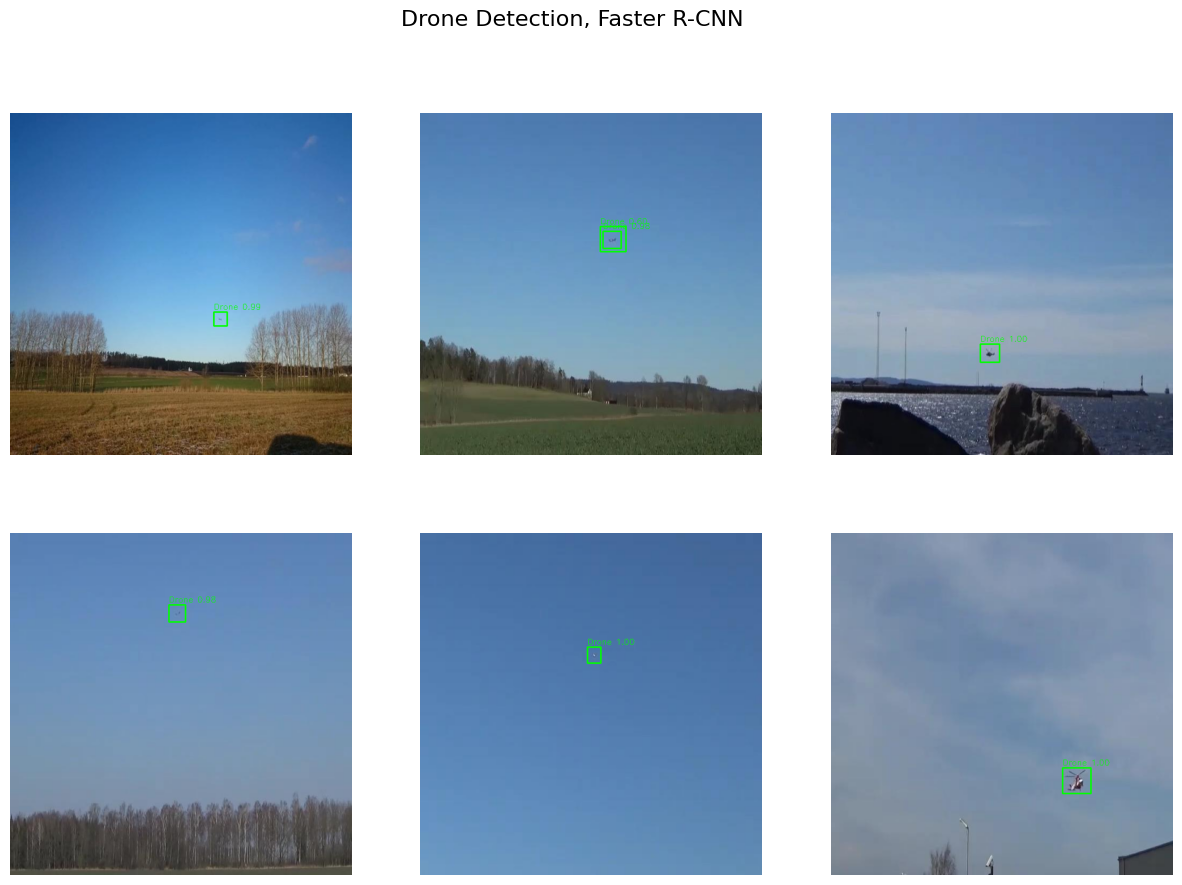

In [21]:
import cv2
import matplotlib.pyplot as plt
import random

def draw_predictions(img, pred, threshold=0.5):
    img = img.copy()

    boxes = pred["boxes"].cpu().numpy()
    scores = pred["scores"].cpu().numpy()

    for box, score in zip(boxes, scores):
        if score < threshold:
            continue
        x1, y1, x2, y2 = map(int, box)
        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(
            img,
            f"Drone {score:.2f}",
            (x1, y1-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0,255,0),
            1
        )

    return img


rcnn.eval()
num_images = 6
indices = random.sample(range(len(val_dataset)), num_images)
plt.figure(figsize=(15,10))

for i, idx in enumerate(indices):
    img, _ = val_dataset[idx]

    with torch.no_grad():
        pred = rcnn([img.to(device)])[0]

    #okazivaetsa v numpy
    img_np = img.permute(1,2,0).cpu().numpy()
    img_np = (img_np * 255).astype("uint8")

    img_out = draw_predictions(img_np, pred, threshold=0.5)

    plt.subplot(2, 3, i+1)
    plt.imshow(img_out)
    plt.axis("off")

plt.suptitle("Drone Detection, Faster R-CNN", fontsize=16)
plt.show()

In [22]:
os.makedirs("present_imgs", exist_ok=True)

for i, idx in enumerate(indices):
    img, _ = val_dataset[idx]

    with torch.no_grad():
        pred = rcnn([img.to(device)])[0]

    img_np = img.permute(1,2,0).cpu().numpy()
    img_np = (img_np * 255).astype("uint8")

    img_out = draw_predictions(img_np, pred)

    cv2.imwrite(f"present_imgs/result_{i}.jpg", cv2.cvtColor(img_out, cv2.COLOR_RGB2BGR))

In [23]:
yolo_results = yolo_model.predict(source=os.path.join(yolo_path, "valid/images"), save=True)


image 1/603 /root/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/drone-detection-new.v5-new-train.yolov8/valid/images/V_AIRPLANE_0011_056_png.rf.dbdfc2c5a59d29d4a8285b306607037b.jpg: 640x640 1 AirPlane, 9.2ms
image 2/603 /root/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/drone-detection-new.v5-new-train.yolov8/valid/images/V_AIRPLANE_0011_114_png.rf.22cd928b6b2eadc0e32ebdb541b394d0.jpg: 640x640 1 AirPlane, 7.2ms
image 3/603 /root/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/drone-detection-new.v5-new-train.yolov8/valid/images/V_AIRPLANE_0011_187_png.rf.34139da037f3be8f0e0b4bb28bbdeb2e.jpg: 640x640 1 AirPlane, 7.2ms
image 4/603 /root/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/drone-detection-new.v5-new-train.yolov8/valid/images/V_AIRPLANE_0011_200_png.rf.cb58e16baac750b2f33902759b3afec6.jpg: 640x640 1 AirPlane, 7.2ms
image 5/603 /root/.cache/kagglehub/datasets/cybersimar08/drone-detection/versions/3/dro